In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

C:\Users\DEXP\AppData\Local\Temp\ipykernel_20900\554524002.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.catplot(x="label", kind="count", palette="pink", data=data)


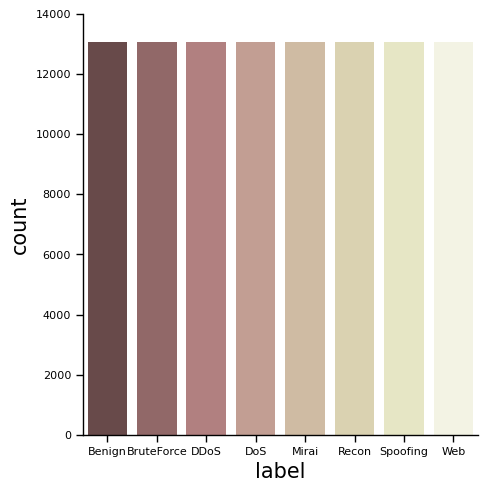

In [7]:
data = pd.read_csv('CICIoT2023-balanced13064.csv') #Загрузка данных
sns.set_context("paper", rc={"axes.labelsize":15})
pl=sns.catplot(x="label", kind="count", palette="pink", data=data)
pl.set_xticklabels(fontsize=8) 
pl.set_yticklabels(fontsize=8)
plt.show()

In [8]:
data.drop(['Unnamed: 0'], axis=1, inplace=True) #Очистка от нулевых значений
data.describe() #Вывод данных

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,104512.000000,1.045120e+05,104512.000000,104512.000000,1.045120e+05,1.045120e+05,1.045120e+05,104512.000000,104512.000000,104512.000000,...,104512.000000,104512.000000,104512.000000,1.045120e+05,104512.000000,104512.000000,104512.000000,1.045120e+05,104512.000000,104512.000000
mean,177.388674,4.351207e+05,11.741938,87.154934,4.388596e+03,4.388596e+03,6.797951e-08,0.015013,0.079618,0.029250,...,369.448717,203.035728,369.411125,8.324190e+07,9.493132,22.458603,286.876387,2.117082e+05,0.563144,141.372873
std,1871.752335,1.141162e+06,11.080860,39.373458,6.041084e+04,6.041084e+04,2.197663e-05,0.121603,0.270702,0.168508,...,519.358179,382.838694,523.111046,6.522641e+07,3.130387,14.871557,541.625591,8.493901e+05,0.436743,80.624405
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,...,42.000000,0.000000,42.000000,8.106232e-07,1.000000,9.165151,0.000000,0.000000e+00,0.000000,1.000000
25%,0.035027,1.080000e+02,6.000000,64.000000,4.793558e+00,4.793558e+00,0.000000e+00,0.000000,0.000000,0.000000,...,57.768827,0.000000,57.600000,2.312167e-02,5.500000,10.741722,0.000000,0.000000e+00,0.000000,38.500000
50%,3.973427,1.090615e+04,7.100000,65.730000,3.006670e+01,3.006670e+01,0.000000e+00,0.000000,0.000000,0.000000,...,123.706552,39.130127,119.900000,8.314939e+07,9.500000,15.602168,55.142315,2.524423e+03,0.800000,141.550000
75%,48.021542,1.435160e+05,13.700000,99.400000,1.158891e+02,1.158891e+02,0.000000e+00,0.000000,0.000000,0.000000,...,554.000000,183.729738,554.000000,1.665180e+08,13.500000,33.286634,258.970591,5.195957e+04,1.000000,244.600000
max,99685.656389,9.815902e+06,47.000000,255.000000,4.194304e+06,4.194304e+06,7.104675e-03,1.000000,1.000000,1.000000,...,7549.361270,7814.299238,8409.200000,1.676394e+08,15.000000,117.256329,11051.087962,6.900415e+07,1.000000,244.600000


In [9]:
print(f"Количество нулей в столбцах {data.isnull().sum()}")

Количество нулей в столбцах flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label 

In [10]:
constant_cols = [col for col in data.columns if data[col].nunique() == 1]
print(f"{constant_cols} Являются констанстыми столбцами и не несут пользы")
data.drop(columns=constant_cols, inplace=True)

['Telnet', 'SMTP', 'IRC', 'DHCP'] Являются констанстыми столбцами и не несут пользы


In [11]:
print(f"Оставшиеся столбцы {data.columns}")

Оставшиеся столбцы Index(['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate',
       'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number',
       'rst_flag_number', 'psh_flag_number', 'ack_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count',
       'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH',
       'TCP', 'UDP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [12]:
print(f"Количество данных/столбцов (shape) {data.shape}")

Количество данных/столбцов (shape) (104512, 43)


In [13]:
def split(data): #Разделение данных
  target_col = data['label']
  data.drop(['label'], axis=1, inplace=True)
  data = (data-data.min()) / (data.max()-data.min())
  target_col.replace('DDoS', 1, inplace=True)
  target_col.replace('DoS', 2, inplace=True)
  target_col.replace('Mirai', 3, inplace=True)
  target_col.replace('Recon', 4, inplace=True)
  target_col.replace('Spoofing', 5, inplace=True)
  target_col.replace('Web', 6, inplace=True)
  target_col.replace('BruteForce', 7, inplace=True)
  target_col.replace('Benign', 0, inplace=True)
  X_train, X_rem, y_train, y_rem = train_test_split(data, target_col, train_size=0.8, random_state=42)
  X_valid, X_test, y_valid, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)
  return X_train, X_rem, y_train, y_rem, X_valid, X_test, y_valid, y_test
X_train, X_rem, y_train, y_rem, X_valid, X_test, y_valid, y_test = split(data)

C:\Users\DEXP\AppData\Local\Temp\ipykernel_20900\3668842586.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target_col.replace('Benign', 0, inplace=True)


In [37]:
# Функция вывода матрицы ошибок
def plot_ermatrix(cm):
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.subplots(figsize=(5, 5))
    sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=['Benign', 'DDoS', 'DoS', 'Mirai', 'Spoofing', 'Recon', 'Web', 'BruteForce'],
                yticklabels=['Benign', 'DDoS', 'DoS', 'Mirai', 'Spoofing', 'Recon', 'Web', 'BruteForce'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show(block=False)

In [4]:
import joblib #Сохранение моделей

In [39]:
#Модель Decision Tree
max_depth = [int(x) for x in np.linspace(10, 50, 5)]
max_depth.append(None)
tree_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [int(x) for x in np.linspace(2, 50, 5)],
    'max_depth': max_depth,
    'random_state': [42]
}
tree_base = DecisionTreeClassifier()
tree_gr = GridSearchCV(estimator=tree_base, param_grid=tree_grid, cv=2, verbose=1) #поиск лучших гиперпраметров
tree_gr.fit(X_train, y_train) 
print(f"Найденые лучшие гиперпараметры {tree_gr.best_params_}")
tree = DecisionTreeClassifier(random_state=42, criterion='entropy', max_depth=20, min_samples_split=38)
tree.fit(X_train, y_train)
joblib.dump(tree, "decision_tree_ciciot2023.pkl") #сохранение

Fitting 2 folds for each of 90 candidates, totalling 180 fits


{'criterion': 'entropy',
 'max_depth': 20,
 'min_samples_split': 38,
 'random_state': 42}

Accuracy:  0.8930348258706468
F1:  0.8921052462548877


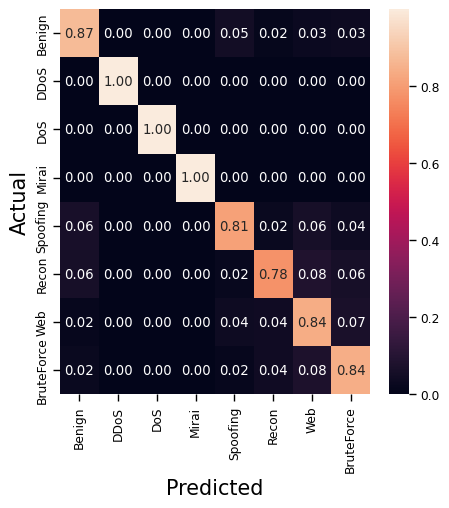

In [41]:
y_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test,y_pred)
tree_f1 = f1_score(y_test,y_pred, average='macro')
print('Accuracy: ', tree_acc)
print('F1: ', tree_f1)
plot_ermatrix(confusion_matrix(y_test, y_pred))

In [42]:
#Модель Random Forest
max_depth = [int(x) for x in np.linspace(10, 50, 5)]
max_depth.append(None)
rf_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'n_estimators': [100, 200, 300],
    'max_depth': max_depth,
    'max_features': ['sqrt', 'log2'],
    'random_state': [42]
}

rf_base = RandomForestClassifier()
rf_gr = GridSearchCV(estimator = rf_base, param_grid = rf_grid, cv = 2, verbose = 2)
rf_gr.fit(X_train, y_train)
print(f"Найденые лучшие гиперпараметры {rf_gr.best_params_}")

Fitting 2 folds for each of 108 candidates, totalling 216 fits
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100, random_state=42; total time=   7.1s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=100, random_state=42; total time=   7.1s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=200, random_state=42; total time=  14.0s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=200, random_state=42; total time=  13.9s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=300, random_state=42; total time=  20.8s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, n_estimators=300, random_state=42; total time=  21.0s
[CV] END criterion=gini, max_depth=10, max_features=log2, n_estimators=100, random_state=42; total time=   6.2s
[CV] END criterion=gini, max_depth=10, max_features=log2, n_estimators=100, random_state=42; total time=   6.0s
[CV] END criterion=gini, max_depth=10, ma

{'criterion': 'gini',
 'max_depth': 40,
 'max_features': 'sqrt',
 'n_estimators': 300,
 'random_state': 42}

In [43]:
rf = RandomForestClassifier(random_state=42, criterion='gini',
                            max_depth=40, max_features='sqrt', n_estimators=300)
rf.fit(X_train, y_train)
joblib.dump(rf, "random_forest_ciciot2023.pkl")

['random_forest_ciciot2023.pkl']

Accuracy:  0.9063337160352086
F1:  0.9056365411021041


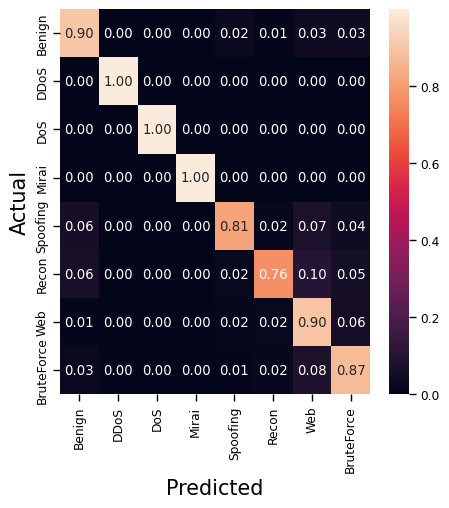

In [44]:
y_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test,y_pred)
rf_f1 = f1_score(y_test,y_pred, average='macro')
print('Accuracy: ', rf_acc)
print('F1: ', rf_f1)
plot_ermatrix(confusion_matrix(y_test, y_pred))

In [18]:
test_df = pd.read_csv("Backdoor_Malware.pcap.csv")
test_df = test_df.drop(columns = 'DHCP')
test_df = test_df.drop(columns = 'IRC')
test_df = test_df.drop(columns = 'SMTP')
test_df = test_df.drop(columns = 'Telnet')
model = joblib.load("random_forest_ciciot2023.pkl")
print(f"Количество нулей в столбцах {test_df.isnull().sum()}")
preds = model.predict(test_df)
test_df.describe()


Количество нулей в столбцах flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
SSH                0
TCP                0
UDP                0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
dtype: int64


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,3218.000000,3218.000000,3218.000000,3218.000000,3.218000e+03,3218.000000,3218.0,3218.000000,3218.000000,3218.000000,...,3218.000000,3218.000000,3218.000000,3.218000e+03,3218.000000,3218.000000,3218.000000,3.218000e+03,3.218000e+03,3218.000000
mean,413.776447,21.017495,9.005904,108.948648,3.074365e+04,1440.272990,0.0,0.018808,0.028403,0.001740,...,306.770160,215.998417,306.770160,8.386699e+07,94.969236,21.226481,264.432383,1.978448e+05,2.471211e+05,141.481914
std,474.965383,7.872175,5.056193,45.662737,3.798187e+05,12691.324355,0.0,0.048724,0.060007,0.015673,...,445.665993,447.803600,445.665993,8.382790e+07,40.013512,12.453857,522.445455,1.116111e+06,1.609736e+06,103.070288
min,0.000010,4.000000,0.000000,35.600000,1.405822e-01,0.015620,0.0,0.000000,0.000000,0.000000,...,63.000000,0.000000,63.000000,3.218651e-06,36.000000,11.155001,0.000000,0.000000e+00,0.000000e+00,25.500000
25%,27.650995,14.400000,6.000000,76.025000,2.217564e+02,0.682692,0.0,0.000000,0.000000,0.000000,...,105.700000,53.618586,105.700000,2.301713e-02,55.000000,14.592671,66.840813,2.590565e+03,2.874953e+03,38.500000
50%,182.726381,20.800000,6.000000,99.900000,4.546586e+02,7.536742,0.0,0.000000,0.000000,0.000000,...,136.400000,73.741621,136.400000,1.676297e+08,55.000000,16.482813,95.571610,5.043027e+03,5.437828e+03,38.500000
75%,731.683933,28.000000,17.000000,131.500000,1.161540e+03,44.118815,0.0,0.000000,0.000000,0.000000,...,201.525000,136.976996,201.525000,1.676298e+08,135.000000,20.189460,176.048484,1.778335e+04,1.876274e+04,244.600000
max,1969.343016,34.400000,17.000000,248.600000,1.665385e+07,282577.420165,0.0,0.400000,0.400000,0.400000,...,4920.000000,7613.456625,4920.000000,1.676299e+08,135.000000,114.617954,6832.145836,2.900759e+07,5.796472e+07,244.600000


In [15]:
print(preds)

[2 6 3 ... 5 6 3]


In [45]:
#Модель kNN
knn_grid = {
    'n_neighbors': [int(x) for x in np.linspace(2, 7, 1)],
    'weights': ['uniform', 'distance'],
    'leaf_size': [20, 30, 50],
    'metric': ['cosine', 'euclidean']
}

knn_base = KNeighborsClassifier()
knn_gr = GridSearchCV(estimator = knn_base, param_grid = knn_grid, cv = 2, verbose = 2)
knn_gr.fit(X_train, y_train)
print(f"Найденые лучшие гиперпараметры {knn_gr.best_params_}")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
[CV] END leaf_size=20, metric=cosine, n_neighbors=2, weights=uniform; total time=  27.2s
[CV] END leaf_size=20, metric=cosine, n_neighbors=2, weights=uniform; total time=  26.4s
[CV] END leaf_size=20, metric=cosine, n_neighbors=2, weights=distance; total time=  24.3s
[CV] END leaf_size=20, metric=cosine, n_neighbors=2, weights=distance; total time=  24.0s
[CV] END leaf_size=20, metric=euclidean, n_neighbors=2, weights=uniform; total time=   5.3s
[CV] END leaf_size=20, metric=euclidean, n_neighbors=2, weights=uniform; total time=   4.4s
[CV] END leaf_size=20, metric=euclidean, n_neighbors=2, weights=distance; total time=   2.1s
[CV] END leaf_size=20, metric=euclidean, n_neighbors=2, weights=distance; total time=   2.1s
[CV] END leaf_size=30, metric=cosine, n_neighbors=2, weights=uniform; total time=  26.4s
[CV] END leaf_size=30, metric=cosine, n_neighbors=2, weights=uniform; total time=  26.3s
[CV] END leaf_size=30, metric=cos

{'leaf_size': 20,
 'metric': 'euclidean',
 'n_neighbors': 2,
 'weights': 'distance'}

Accuracy:  0.7106773823191733
F1:  0.7090382881393984


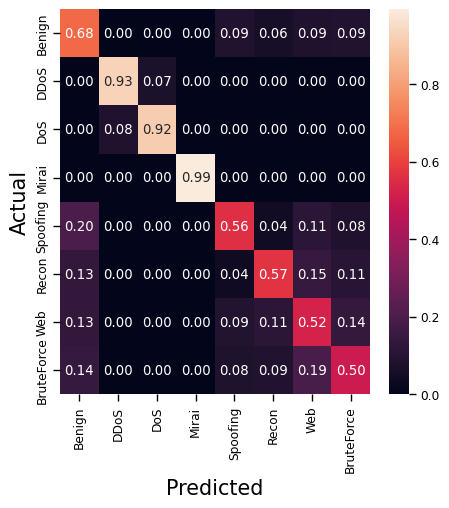

In [46]:
knn = KNeighborsClassifier(leaf_size=40, metric='euclidean', n_neighbors=4)
knn.fit(X_train, y_train)

joblib.dump(knn, "knn_ciciot2023.pkl")

y_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test,y_pred)
knn_f1 = f1_score(y_test,y_pred, average='macro')
print('Accuracy: ', knn_acc)
print('F1: ', knn_f1)
plot_ermatrix(confusion_matrix(y_test, y_pred))

w:\anaconda2\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:10:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  0.9108304630692691
F1:  0.9100473928429563


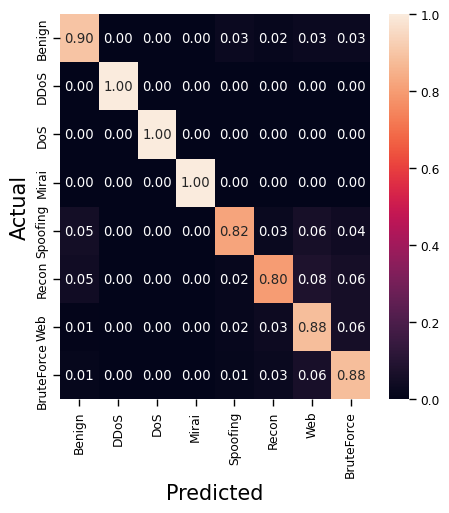

In [52]:
#Модель XGBoost
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

param = {
   'max_depth': 20,
   'eta': 0.3,
   'silent': 1,
   'objective': 'multi:softprob',
   'num_class': 8}
num_round = 20

bst = xgb.train(param, dtrain, num_round)
bst.save_model("xgb_model.json")
preds = bst.predict(dtest)
y_pred = np.asarray([np.argmax(line) for line in preds])

xgb_acc = accuracy_score(y_test,y_pred)
xgb_f1 = f1_score(y_test,y_pred, average='macro')
print('Accuracy: ', xgb_acc)
print('F1: ', xgb_f1)
plot_ermatrix(confusion_matrix(y_test, y_pred))